In [1]:
import pandas as pd
import numpy as np

In [2]:
df = pd.read_csv("dataset_100k_upgraded_previous.csv")
df

,themes,solution,epd,rating,rating_dev,to_move,cp_eval,move1cp,nodes,move1multiPV,...,possible_L2,possible_L3,all_possible_moves,all_narrow_solutions,tree_size,move_ratio_L1,move_ratio_L2,move_ratio_L3,sum_distance,avg_distance
0,crushing hangingPiece long middlegame,f2g3 e6e7 b2b1 b3c1 b1c1 h6c1,r6k/pp2r2p/4Rp1Q/3p4/8/1N1P2b1/PqP3PP/7K w - -,1935,76,1,742,785,2151415,1,...,1399,48160,49598,3,3,0.025641,0.000715,0.000021,4,1.333333
1,advantage endgame short,d3d6 f8d8 d6d8 f6d8,5rk1/1p3ppp/pq1Q1b2/8/8/1P3N2/P4PPP/3R2K1 b - -,1414,75,-1,468,470,338132,1,...,1403,47263,48699,3,3,0.030303,0.000713,0.000021,6,2.000000
2,advantage endgame rookEndgame short,e7f7 f5e5 e2f1 e5e6,8/5R2/1p2P3/p4r2/P6p/1P3Pk1/4K3/8 b - -,1385,80,-1,243,290,265488,1,...,281,4156,4453,0,0,0.000000,0.000000,0.000000,0,0.000000
3,advantage middlegame short,b6c5 e2g4 h3g4 d1g4,r2qr1k1/b1p2ppp/p5n1/P1p1p3/4P1n1/B2P2Pb/3NBP1...,1084,74,1,281,277,94038,1,...,831,21271,22124,3,3,0.045455,0.001203,0.000047,6,2.000000
4,crushing endgame fork short,e4d2 d4e2 g1f1 e2c3,6k1/5p1p/4p3/4q3/3n4/2Q3P1/PP1N1P1P/6K1 b - -,1550,75,-1,549,550,546839,1,...,960,28443,29436,3,3,0.030303,0.001042,0.000035,5,1.666667
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
245,crushing endgame short,e8e4 d1d8 g8h7 f3g5,6k1/pp3pp1/2p5/7b/4r2P/2P2N2/PP4K1/3R4 w - -,804,104,1,523,535,206948,1,...,931,24418,25382,3,3,0.030303,0.001074,0.000041,10,3.333333
246,advancedPawn advantage endgame long rookEndgame,a4a3 a6a7 d3d8 e2e3 a3a2 e3a3,8/2p1pk1p/Pp4p1/8/2P2P2/p2r2P1/3PR2P/3K4 w - -,2235,76,1,290,283,357385,1,...,403,7091,7511,0,0,0.000000,0.000000,0.000000,0,0.000000
247,crushing endgame short,c2a2 h6g6 g3f2 g6g2,8/1bpp2k1/1p5r/1P2P3/3P1P2/2P1n1K1/Q5P1/8 b - -,1735,75,-1,530,516,107308,1,...,792,24798,25626,1,16,0.027778,0.002525,0.000524,36,2.250000
248,crushing discoveredAttack discoveredCheck endg...,h2h3 d8d3 g2g3 d3g3 h3h2 g3c3,3r4/4kp1p/1PQ1p1p1/p3b3/1p2P2P/1P5K/6P1/8 b - -,1264,75,-1,864,917,978487,1,...,739,17213,17987,3,3,0.028571,0.001353,0.000058,9,3.000000


In [3]:
for c in df.select_dtypes(exclude=["int", "float"]).columns:
    print(c)

themes
solution
epd


In [4]:
df1 = df.copy()
df1 = df1[
    (df1["mateIn1"] == 1) | 
    (df1["mateIn2"] == 1) | 
    (df1["mateIn3"] == 1) | 
    (df1["mateIn4"] == 1) | 
    (df1["mateIn5"] == 1)
]

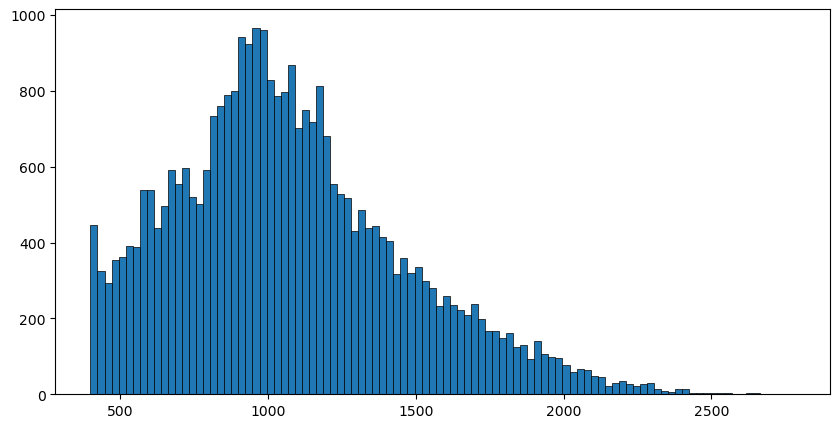

In [5]:
import matplotlib.pyplot as plt
y1 = df1["rating"]
plt.figure(figsize=(10,5))
plt.hist(y1, bins=100, edgecolor="black", linewidth=0.5)
plt.show()

In [3]:
y = df["rating"]

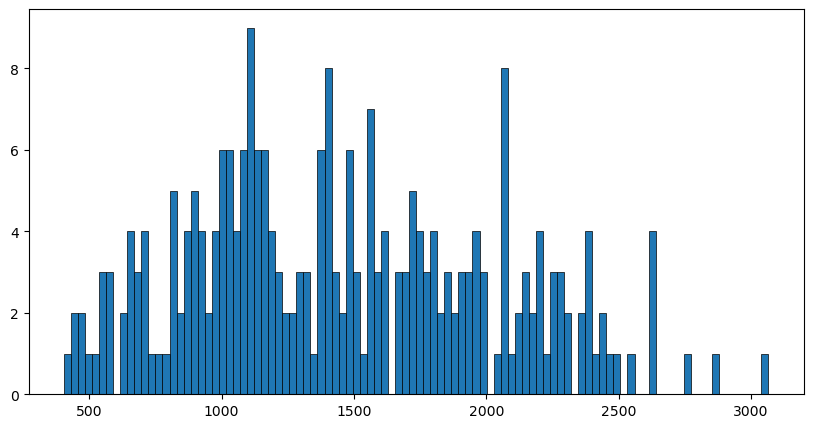

In [12]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))
plt.hist(y, bins=100, edgecolor="black", linewidth=0.5)
plt.show()

In [4]:
remove_attributes = []
for c in df["themes"]:
    remove_attributes.extend(c.split(" "))
#remove_attributes = []

In [5]:
X = df.drop(columns=["themes", "solution", "epd", "rating_dev", "rating"] + remove_attributes)
X

,to_move,cp_eval,move1cp,nodes,move1multiPV,move1sel_depth,move1w,move1d,move1l,move2cp,...,possible_L2,possible_L3,all_possible_moves,all_narrow_solutions,tree_size,move_ratio_L1,move_ratio_L2,move_ratio_L3,sum_distance,avg_distance
0,1,742,785,2151415,1,62,1000,0,0,-559,...,1399,48160,49598,3,3,0.025641,0.000715,0.000021,4,1.333333
1,-1,468,470,338132,1,32,1000,0,0,31,...,1403,47263,48699,3,3,0.030303,0.000713,0.000021,6,2.000000
2,-1,243,290,265488,1,31,1000,0,0,-314,...,281,4156,4453,0,0,0.000000,0.000000,0.000000,0,0.000000
3,1,281,277,94038,1,25,999,1,0,-157,...,831,21271,22124,3,3,0.045455,0.001203,0.000047,6,2.000000
4,-1,549,550,546839,1,38,1000,0,0,-211,...,960,28443,29436,3,3,0.030303,0.001042,0.000035,5,1.666667
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
245,1,523,535,206948,1,29,1000,0,0,-178,...,931,24418,25382,3,3,0.030303,0.001074,0.000041,10,3.333333
246,1,290,283,357385,1,40,1000,0,0,-162,...,403,7091,7511,0,0,0.000000,0.000000,0.000000,0,0.000000
247,-1,530,516,107308,1,22,1000,0,0,0,...,792,24798,25626,1,16,0.027778,0.002525,0.000524,36,2.250000
248,-1,864,917,978487,1,49,1000,0,0,-153,...,739,17213,17987,3,3,0.028571,0.001353,0.000058,9,3.000000


In [6]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=67)
print(X_train.shape)
print(y_train.shape)
print(X_test.shape)
print(y_test.shape)

(200, 89)
(200,)
(50, 89)
(50,)


In [7]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import mean_absolute_error as MAE

y_min = np.min(y_train)
y_max = np.max(y_train)
def NMAE(y_test, y_pred):
    return MAE(y_test, y_pred)/(y_max - y_min)

#model = RandomForestClassifier(n_estimators=100, random_state=42)
#model.fit(X_train, y_train)
#y_pred = model.predict(X_test)

#print(f"MAE: {MAE(y_test, y_pred)}")

In [8]:
from xgboost import XGBRegressor

model = XGBRegressor(
    n_estimators=100,
    learning_rate=0.1,
    eval_metric="mae"
)
model.fit(X_train, y_train)
y_pred = model.predict(X_test)

print(f"MAE: {MAE(y_test, y_pred)}")
print(f"NMAE: {NMAE(y_test, y_pred)}")

MAE: 428.67186645507815
NMAE: 0.1610942752555724


In [9]:
from sklearn.feature_selection import mutual_info_regression

mi_scores = mutual_info_regression(X_train, y_train)

In [11]:
best_features_mi = {name: round(float(mi_scores[i]), 4) for i, name in enumerate(X.columns.values)}
best_features_mi = dict(sorted(best_features_mi.items(), key=lambda item: item[1], reverse=True))
#best_features_mi

In [16]:
choose_features = list(best_features_mi.keys())[75:]
#choose_features

In [17]:
#X = df.drop(columns=["themes", "solution", "epd", "rating_dev", "rating"])
#X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=67)

In [13]:
# https://scikit-learn.org/stable/developers/develop.html
from sklearn.base import BaseEstimator, RegressorMixin
from sklearn.tree import DecisionTreeRegressor
from sklearn.base import is_classifier, is_regressor

class HierarchicalEnsembleRegressor(RegressorMixin, BaseEstimator):
    def __init__(self, main_model, submodels, bin_overlap=0.0):
        self.main_model = main_model
        self.submodels = submodels
        self.bin_overlap = bin_overlap
        
    def fit(self, X, y):
        X = X.values if hasattr(X, "values") else np.array(X)
        y = y.values if hasattr(y, "values") else np.array(y)

        self.y_min = np.min(y)
        self.y_max = np.max(y)
        X_bins, y_bins = self.get_bins(X, y)

        for i, c in enumerate(zip(X_bins, y_bins)):
            X_bin, y_bin = c
            self.submodels[i].fit(X_bin, y_bin)

        if is_classifier(self.main_model):
            y_bin = self.target_to_bin(y)
            self.main_model.fit(X, y_bin)
        elif is_regressor(self.main_model):
            self.main_model.fit(X, y)
        else:
            #raise ValueError("main_model is neither a recognized classifier nor a regressor!")
            y_bin = self.target_to_bin(y)
            self.main_model.fit(X, y_bin)
    
    def predict(self, X):
        X = X.values if hasattr(X, "values") else np.array(X)

        y_bin_pred = self.predict_bin(X)
        final_pred = np.zeros(len(X))
    
        for i in range(len(self.submodels)):
            mask = (y_bin_pred == i)
            if np.any(mask):
                final_pred[mask] = self.submodels[i].predict(X[mask])
            
        return final_pred

    def predict_bin(self, X):
        if is_classifier(self.main_model):
            return self.main_model.predict(X)
        elif is_regressor(self.main_model):
            y_pred = self.main_model.predict(X)
            return self.target_to_bin(y_pred)
        else:
            #raise ValueError("main_model is neither a recognized classifier nor a regressor!")
            return self.main_model.predict(X)
    
    def get_bins(self, X, y):
        X = X.values if hasattr(X, "values") else np.array(X)
        y = y.values if hasattr(y, "values") else np.array(y)
        N = len(self.submodels)
        width = (self.y_max - self.y_min) / N
    
        i_max = np.floor(((y - self.y_min) + self.bin_overlap) / width).astype(int)
        i_min = np.ceil(((y - self.y_min) - width - self.bin_overlap) / width).astype(int)
        i_min = np.clip(i_min, 0, N - 1)
        i_max = np.clip(i_max, 0, N - 1)
        
        X_bins = [[] for _ in range(N)]
        y_bins = [[] for _ in range(N)]
        
        for j in range(len(y)):
            for b in range(i_min[j], i_max[j] + 1):
                X_bins[b].append(X[j])
                y_bins[b].append(y[j])
    
        X_bins = [np.array(b) for b in X_bins]
        y_bins = [np.array(b) for b in y_bins]
        
        return X_bins, y_bins

    def target_to_bin(self, y):
        N = len(self.submodels)
        width = (self.y_max - self.y_min) / N
        bins = np.floor((y - self.y_min) / width).astype(int)
        return np.clip(bins, 0, N - 1)
        

In [14]:
from sklearn.ensemble import HistGradientBoostingClassifier
from sklearn.linear_model import LogisticRegression

In [15]:
from xgboost import XGBRegressor
from sklearn.ensemble import RandomForestClassifier

In [40]:
import mord
main_model = mord.LogisticAT(alpha=0.5)
main_model._estimator_type = "classifier"

bins = 4
submodels = [XGBRegressor(n_estimators=100, learning_rate=0.1, eval_metric=NMAE) for _ in range(bins)]

In [16]:
bins = 4
main_model = LogisticRegression(max_iter=1000)

submodels = [XGBRegressor(n_estimators=100, learning_rate=0.1, eval_metric=NMAE) for _ in range(bins)]

In [ ]:
bins = 4
main_model = XGBClassifier?

submodels = [XGBRegressor(n_estimators=100, learning_rate=0.1, eval_metric="mae") for _ in range(bins)]

In [58]:
bins = 4
main_model = XGBRegressor(
    n_estimators=100,
    learning_rate=0.1,
    eval_metric="mae"
)

submodels = [XGBRegressor(n_estimators=100, learning_rate=0.1, eval_metric="mae") for _ in range(bins)]

In [42]:
bins = 2
main_model = RandomForestClassifier(n_estimators=100, random_state=42)

submodels = [XGBRegressor(n_estimators=100, learning_rate=0.1, eval_metric="mae") for _ in range(bins)]

In [18]:
bins = 4
main_model = HistGradientBoostingClassifier(
    max_iter=100,
    max_depth=5,
    learning_rate=0.1, 
    categorical_features=None
)

submodels = [XGBRegressor(n_estimators=100, learning_rate=0.1, eval_metric="mae") for _ in range(bins)]

In [19]:
model = HierarchicalEnsembleRegressor(main_model, submodels, bin_overlap=100)
model.fit(X_train, y_train)
y_pred = model.predict(X_test)

print(f"MAE: {MAE(y_test, y_pred)}")
print(f"NMAE: {NMAE(y_test, y_pred)}")

MAE: 426.1939416503906
NMAE: 0.16016307465253313


In [31]:
y_true_bins = model.target_to_bin(y_test)

In [21]:
from collections import Counter 
counts = Counter(y_true_bins)
total = sum(counts.values())

{b: round(c / total, 2) for b, c in counts.items()}

{2: 0.26, 1: 0.42, 3: 0.05, 0: 0.27}

In [21]:
y_pred = model.main_model.predict(X_test)
print(f"MAE: {MAE(y_test, y_pred)}")

C:\Users\matejck\.conda\envs\chess-ai\Lib\site-packages\sklearn\base.py:486: UserWarning: X has feature names, but HistGradientBoostingClassifier was fitted without feature names
  warnings.warn(


MAE: 1468.06


In [22]:
y_true_bins = model.target_to_bin(y_test)
y_pred_bins = model.main_model.predict(X_test)

C:\Users\matejck\.conda\envs\chess-ai\Lib\site-packages\sklearn\base.py:486: UserWarning: X has feature names, but HistGradientBoostingClassifier was fitted without feature names
  warnings.warn(


In [23]:
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
acc = accuracy_score(y_true_bins, y_pred_bins)
print(f"Router Accuracy: {acc:.2%}")

print(classification_report(y_true_bins, y_pred_bins))

Router Accuracy: 56.00%
              precision    recall  f1-score   support

           0       0.65      0.69      0.67        16
           1       0.42      0.73      0.54        15
           2       0.83      0.33      0.48        15
           3       1.00      0.25      0.40         4

    accuracy                           0.56        50
   macro avg       0.73      0.50      0.52        50
weighted avg       0.66      0.56      0.55        50



In [48]:
y_bins_train

[array([ 855, 1123, 1059, ...,  848, 1265, 1109], shape=(28536,)),
 array([1449, 1684, 1123, ..., 1265, 1109, 1928], shape=(45034,)),
 array([1684, 2092, 1796, ..., 1979, 2011, 2412], shape=(27868,)),
 array([2918, 2489, 2234, ..., 2518, 2603, 2412], shape=(7577,))]

In [119]:
X_bins_train, y_bins_train = model.get_bins(X_train, y_train)
X_bins_test, y_bins_test = model.get_bins(X_test, y_test)

for i, c in enumerate(zip(X_bins_test, y_bins_test)):
    X_bin_test, y_bin_test = c
    y_bin_pred = model.submodels[i].predict(X_bin_test)
    print(f"Model {i}:")
    print(f"Interval: [{min(y_bins_train[i])}, {max(y_bins_train[i])}]")
    width = max(y_bins_train[i]) - min(y_bins_train[i]) + 1
    print(f"Width: {width}")
    print(f"Samples: {len(y_bins_train[i])}")
    print(f"MAE: {MAE(y_bin_pred, y_bin_test)}")
    print(f"NMAE: {width/MAE(y_bin_pred, y_bin_test)}")
    print()

Model 0:
Interval: [399, 1845]
Width: 1447
Samples: 51180
MAE: 214.86549377441406
NMAE: 6.734445697079663

Model 1:
Interval: [1646, 3092]
Width: 1447
Samples: 25473
MAE: 208.53179931640625
NMAE: 6.938989663655375



In [156]:
N = len(model.submodels)
submodel_matrix = np.zeros((N, N))

X_bins_train, y_bins_train = model.get_bins(X_train, y_train)
X_bins_test, y_bins_test = model.get_bins(X_test, y_test)

X_bins, y_bins = X_bins_test, y_bins_test

for i, submodel in enumerate(model.submodels):
    for j, c in enumerate(zip(X_bins, y_bins)):
        X_bin, y_bin = c
        y_bin_pred = model.submodels[i].predict(X_bin)
        mae = MAE(y_bin_pred, y_bin)
        # NMAE = width/MAE(y_bin_pred, y_bin_test)

        submodel_matrix[i, j] = mae     

In [150]:
N = len(model.submodels)
main_model_matrix = np.zeros((N, N))

y_true_bins = model.target_to_bin(y_test)
predicted_bins = model.predict_bin(X_test)

for true, predicted in zip(y_true_bins, predicted_bins):
    main_model_matrix[true, predicted] += 1

C:\Users\Matej\.conda\envs\chess-ai\Lib\site-packages\sklearn\utils\validation.py:2684: UserWarning: X has feature names, but LogisticRegression was fitted without feature names
  warnings.warn(


In [151]:
main_model_matrix

array([[1.8020e+03, 6.0250e+03, 8.3000e+01, 0.0000e+00],
       [1.0860e+03, 1.1207e+04, 2.6700e+02, 0.0000e+00],
       [2.5000e+02, 7.1370e+03, 2.9900e+02, 2.0000e+00],
       [2.6000e+01, 1.4190e+03, 1.0800e+02, 5.0000e+00]])

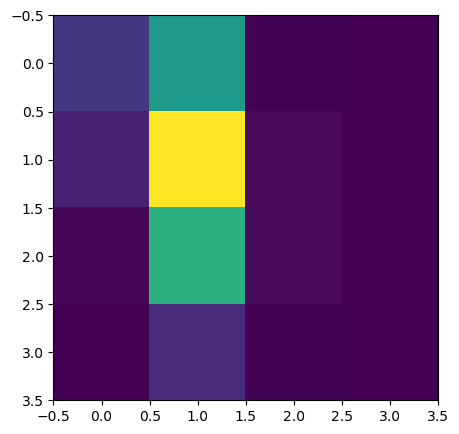

In [153]:
plt.figure(figsize=(6, 5))
plt.imshow(main_model_matrix, interpolation='nearest')
plt.show()

In [158]:
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap

def plot_heatmap(data, colors=["#00FF00", "#FFFF00", "#FF0000"]):
    cmap = LinearSegmentedColormap.from_list("custom_green_red", colors)
    
    # Plot the confusion matrix using pure matplotlib
    fig, ax = plt.subplots(figsize=(6, 5))
    cax = ax.imshow(data, interpolation='nearest', cmap=cmap)
    
    # Add color bar on the right
    fig.colorbar(cax)
    
    # Add text annotations inside the squares using a nested loop
    for i in range(data.shape[0]):
        for j in range(data.shape[1]):
            ax.text(j, i, f"{data[i, j]:.2f}", 
                    ha="center", va="center", color="black", fontsize=14)
    
    # Set the tick marks and labels for the axes
    ax.set_xticks(np.arange(data.shape[1]))
    ax.set_yticks(np.arange(data.shape[0]))
    
    # Add titles and labels
    plt.title("Confusion Matrix", fontsize=16)
    plt.xlabel("Predicted Label", fontsize=12)
    plt.ylabel("True Label", fontsize=12)
    plt.tight_layout()

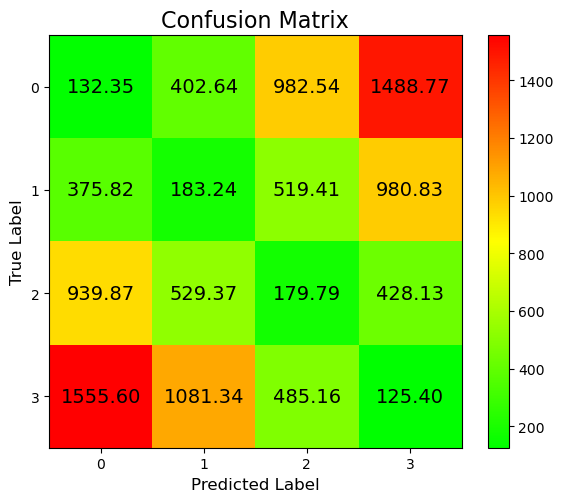

In [159]:
plot_heatmap(submodel_matrix)

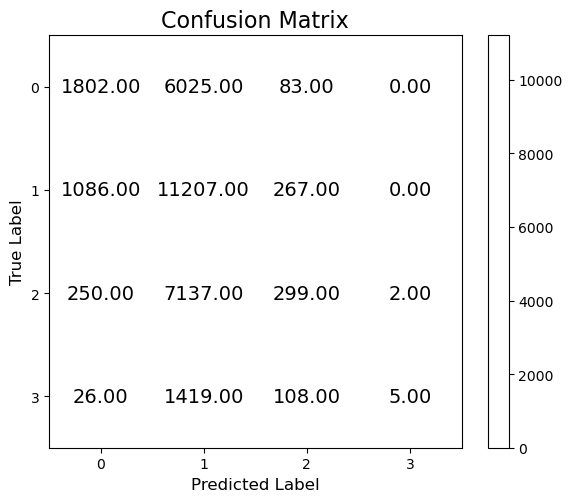

In [162]:
plot_heatmap(main_model_matrix, colors=["#FFFFFF", "#FFFFFF", "#FFFFFF"])